# rPINN logistic growth with heteroscedastic AR(1) noise

This notebook runs the randomized PINN version with fixed data and physics loss uncertainties of 0.1.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from config import ExperimentConfig
from data import generate_synthetic_data, compute_noise_summary
from training import fit_multi_ic_rpinn, fit_sigma_ar1_repeated
from utils import set_seed, mean_and_ci
from diagnostics import plot_percentage_error_vs_state


In [2]:
# ============================================================
# Setup
# ============================================================
cfg = ExperimentConfig(noise_sig_coeff=0.05)
device = torch.device(cfg.device)

set_seed(cfg.seed_torch, cfg.seed_numpy)

# ============================================================
# Generate data
# ============================================================
data = generate_synthetic_data(cfg, device)

t_obs = data["t_obs"]
t_plot = data["t_plot"]
N_grid = data["N_grid"]
y_true_all = data["y_true_all"]
y_data_all = data["y_data_all"]
noise_all = data["noise_all"]
H_grid_true = data["H_grid_true"]
G_grid_true = data["G_grid_true"]
sigma_true_grid = data["sigma_true_grid"]

n_ics = len(cfg.N0_list)

In [3]:
# ============================================================
# Noise summary
# ============================================================
stats = compute_noise_summary(
    y_true_all=y_true_all,
    y_data_all=y_data_all,
    noise_sig_coeff=cfg.noise_sig_coeff,
    gamma=cfg.gamma,
)

print("\nNoise summary")
print("-------------")
print(f"rho_true: {cfg.rho_true:.4f}")
print(f"mean signed noise: {stats['noise_np'].mean():.6e}")
print(f"std signed noise : {stats['noise_np'].std(ddof=1):.6e}")
print(f"mean abs noise   : {stats['abs_noise_np'].mean():.6e}")
print(f"RMSE noise       : {np.sqrt(np.mean(stats['noise_np']**2)):.6e}")
print(f"mean sigma_true  : {stats['sigma_true_obs_np'].mean():.6e}")


Noise summary
-------------
rho_true: 0.5000
mean signed noise: -2.732968e-04
std signed noise : 3.427377e-02
mean abs noise   : 2.385342e-02
RMSE noise       : 3.409589e-02
mean sigma_true  : 3.149933e-02


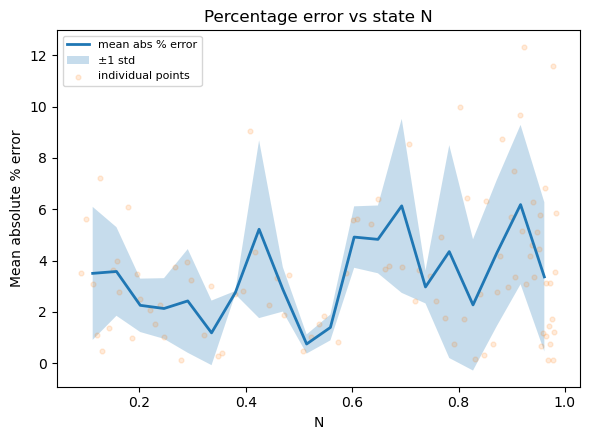

In [4]:
plot_percentage_error_vs_state(y_true_all, y_data_all)

In [12]:
# ============================================================
# Learn sigma(N, t), rho from true residuals
# ============================================================
t_obs = data["t_obs"].to(device=device, dtype=torch.float32)

with torch.no_grad():
    # shapes before adding the last singleton dimension:
    #   y_true_all, y_data_all: [B, T, 1]  (or compatible)
    N_true_seq_np = y_true_all.squeeze(-1).cpu().numpy()
    resid_true_seq_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy()

    # avoid exactly zero / negative state values if sigma model expects positive-state regime
    N_true_seq_np = np.maximum(N_true_seq_np, 1e-8)

# shape: [B, T, 1]
N_true_seq = torch.tensor(
    N_true_seq_np[..., None],
    dtype=torch.float32,
    device=device,
)
resid_true_seq = torch.tensor(
    resid_true_seq_np[..., None],
    dtype=torch.float32,
    device=device,
)

# build time tensor with shape [B, T, 1] so it matches N_true_seq/resid_true_seq
# t_obs is assumed shape [T, 1] or [T]
if t_obs.ndim == 1:
    t_obs = t_obs.unsqueeze(-1)
t_obs_sigma = t_obs.unsqueeze(0).expand(N_true_seq.shape[0], -1, -1)

# ------------------------------------------------------------
# Sigma evaluation / monotonicity grids
# ------------------------------------------------------------
# sigma(N, t) needs both N and t for evaluation.
# For 1D plotting/inspection of sigma versus N, use a fixed reference time.
t_ref = 0.5 * (t_obs.min() + t_obs.max())

# evaluate sigma on N_grid at reference time t_ref
N_eval_grid_sigma = N_grid
t_eval_grid_sigma = torch.full_like(N_grid, t_ref)

# monotonicity penalty enforces monotone-in-N while holding time fixed
N_col_base_sigma = N_grid
t_col_base_sigma = torch.full_like(N_grid, t_ref)


# ============================================================
# Train multi-IC rPINN
# ============================================================

# intended updated settings
cfg.use_learned_sigma_rpinn = True
cfg.sigma_eval_mode = "predicted_state"   # or "observed_state"
cfg.sigma_detach_state = True
cfg.sigma_floor_rpinn = 1e-4
cfg.n_epochs_pinn = 5000
cfg.n_rpinn_samples = 10

# optional but useful sanity checks
assert N_true_seq.shape == resid_true_seq.shape, (
    f"N_true_seq shape {N_true_seq.shape} must match resid_true_seq shape {resid_true_seq.shape}"
)
assert t_obs_sigma.shape == N_true_seq.shape, (
    f"t_obs_sigma shape {t_obs_sigma.shape} must match N_true_seq shape {N_true_seq.shape}"
)

# 1) fit learned sigma(N, t) and AR(1) rho
sigma_result = fit_sigma_ar1_repeated(
    N_seq_all=N_true_seq,
    t_seq_all=t_obs_sigma,
    resid_seq_all=resid_true_seq,
    N_eval_grid=N_eval_grid_sigma,
    t_eval_grid=t_eval_grid_sigma,
    N_col_base=N_col_base_sigma,
    t_col_base=t_col_base_sigma,
    device=device,
    n_repeats=cfg.n_repeats_sigma,
    val_fraction=cfg.val_fraction_sigma,
    n_epochs=cfg.n_epochs_sigma,
    lr=cfg.lr_sigma,
    hidden_dim=cfg.hidden_dim_sigma,
    lambda_mon=cfg.lambda_mon,
    lambda_reg=cfg.lambda_reg,
    seed_offset_split=cfg.sigma_split_seed_base_1,
    seed_offset_model=cfg.sigma_model_seed_base_1,
    print_every=cfg.print_every_sigma,
)

# optional: pull out fitted rho / sigma summary
sigma_best_rhos = sigma_result["best_rhos"]
sigma_curve_histories = sigma_result["curve_histories"]

# 2) train multi-IC rPINN using learned sigma(N, t)
rpinn_out = fit_multi_ic_rpinn(
    cfg=cfg,
    y_data_all=y_data_all,
    t_obs=t_obs,
    t_plot=t_plot,
    N_grid=N_grid,
    n_ics=n_ics,
    device=device,
    sigma_fit_result=sigma_result,   # learned sigma(N, t)
)

# ------------------------------------------------------------
# unpack outputs
# ------------------------------------------------------------
rhs_mean = rpinn_out["rhs_mean"]
rhs_lo = rpinn_out["rhs_lo"]
rhs_hi = rpinn_out["rhs_hi"]

traj_mean_per_ic = rpinn_out["traj_mean_per_ic"]
traj_lo_per_ic = rpinn_out["traj_lo_per_ic"]
traj_hi_per_ic = rpinn_out["traj_hi_per_ic"]

obs_fit_mean_per_ic = rpinn_out["obs_fit_mean_per_ic"]
obs_fit_lo_per_ic = rpinn_out["obs_fit_lo_per_ic"]
obs_fit_hi_per_ic = rpinn_out["obs_fit_hi_per_ic"]

# optional MAP outputs
map_rhs = rpinn_out["map_rhs"]
map_traj = rpinn_out["map_traj"]
map_obs_fit = rpinn_out["map_obs_fit"]

# optional diagnostics
best_train_losses = rpinn_out["best_train_losses"]
best_epochs = rpinn_out["best_epochs"]
uses_learned_sigma = rpinn_out["uses_learned_sigma"]
sigma_eval_mode = rpinn_out["sigma_eval_mode"]
sigma_floor = rpinn_out["sigma_floor"]

sigma-ar1-markov-nt | Repeat 1/1 | Epoch 1/2000 | rho=0.0050 | Train Total=4.611955e-02 | Train NLL=4.607503e-02 | Train Reg=4.451460e-05 | Val Total=1.438507e-02
sigma-ar1-markov-nt | Repeat 1/1 | Epoch 250/2000 | rho=0.5975 | Train Total=-3.027415e+00 | Train NLL=-3.027686e+00 | Train Reg=2.114971e-04 | Val Total=-3.232920e+00
sigma-ar1-markov-nt | Repeat 1/1 | Epoch 500/2000 | rho=0.5964 | Train Total=-3.033500e+00 | Train NLL=-3.033770e+00 | Train Reg=2.523009e-04 | Val Total=-3.238742e+00
sigma-ar1-markov-nt | Repeat 1/1 | Epoch 750/2000 | rho=0.5959 | Train Total=-3.034925e+00 | Train NLL=-3.035210e+00 | Train Reg=2.774537e-04 | Val Total=-3.240087e+00
sigma-ar1-markov-nt | Repeat 1/1 | Epoch 1000/2000 | rho=0.5958 | Train Total=-3.035528e+00 | Train NLL=-3.035826e+00 | Train Reg=2.947876e-04 | Val Total=-3.240649e+00
sigma-ar1-markov-nt | Repeat 1/1 | Epoch 1250/2000 | rho=0.5958 | Train Total=-3.035973e+00 | Train NLL=-3.036279e+00 | Train Reg=3.065307e-04 | Val Total=-3.241049

In [6]:
# ============================================================
# Learn sigma(N, t), rho from PINN residuals
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)              # shape [B, T]
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()             # shape [B, T]

    resid_pinn_seq_np = y_data_np - obs_fit_mean_all
    N_pinn_seq_np = np.maximum(obs_fit_mean_all, 1e-8)

N_pinn_seq = torch.tensor(
    N_pinn_seq_np[..., None],
    dtype=torch.float32,
    device=device,
)
resid_pinn_seq = torch.tensor(
    resid_pinn_seq_np[..., None],
    dtype=torch.float32,
    device=device,
)

# t_obs should already exist from:
# t_obs = data["t_obs"].to(device=device, dtype=torch.float32)
if t_obs.ndim == 1:
    t_obs = t_obs.unsqueeze(-1)

# shape [B, T, 1], matched to N_pinn_seq / resid_pinn_seq
t_pinn_seq = t_obs.unsqueeze(0).expand(N_pinn_seq.shape[0], -1, -1)

# ------------------------------------------------------------
# Sigma evaluation / monotonicity grids for sigma(N, t)
# ------------------------------------------------------------
N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_seq.max().item())),
    200,
    device=device,
    dtype=torch.float32,
).view(-1, 1)

# evaluate sigma(N, t) on a fixed reference time for plotting vs N
t_ref = 0.5 * (t_obs.min() + t_obs.max())

N_eval_grid_sigma_pinn = N_grid
t_eval_grid_sigma_pinn = torch.full_like(N_eval_grid_sigma_pinn, t_ref)

# monotonicity in N while holding t fixed
t_col_base_sigma_pinn = torch.full_like(N_sigma_col_base, t_ref)

# optional sanity checks
assert N_pinn_seq.shape == resid_pinn_seq.shape, (
    f"N_pinn_seq shape {N_pinn_seq.shape} must match resid_pinn_seq shape {resid_pinn_seq.shape}"
)
assert t_pinn_seq.shape == N_pinn_seq.shape, (
    f"t_pinn_seq shape {t_pinn_seq.shape} must match N_pinn_seq shape {N_pinn_seq.shape}"
)

sigma_pinn_results = fit_sigma_ar1_repeated(
    N_seq_all=N_pinn_seq,
    t_seq_all=t_pinn_seq,
    resid_seq_all=resid_pinn_seq,
    N_eval_grid=N_eval_grid_sigma_pinn,
    t_eval_grid=t_eval_grid_sigma_pinn,
    N_col_base=N_sigma_col_base,
    t_col_base=t_col_base_sigma_pinn,
    device=device,
    n_repeats=cfg.n_repeats_sigma,
    val_fraction=cfg.val_fraction_sigma,
    n_epochs=cfg.n_epochs_sigma,
    lr=cfg.lr_sigma,
    hidden_dim=cfg.hidden_dim_sigma,
    lambda_mon=cfg.lambda_mon,
    lambda_reg=cfg.lambda_reg,
    seed_offset_split=cfg.sigma_split_seed_base_1,
    seed_offset_model=cfg.sigma_model_seed_base_1,
    label="PINN-sigma-AR1-nt",
    print_every=cfg.print_every_sigma,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)
rho_pinn_mean = sigma_pinn_results["best_rhos"].mean()
rho_pinn_lo = np.percentile(sigma_pinn_results["best_rhos"], 2.5)
rho_pinn_hi = np.percentile(sigma_pinn_results["best_rhos"], 97.5)

PINN-sigma-AR1-nt | Repeat 1/1 | Epoch 1/2000 | rho=0.0050 | Train Total=4.574888e-02 | Train NLL=4.570437e-02 | Train Reg=4.451460e-05 | Val Total=1.432147e-02
PINN-sigma-AR1-nt | Repeat 1/1 | Epoch 250/2000 | rho=0.2095 | Train Total=-3.290340e+00 | Train NLL=-3.290599e+00 | Train Reg=2.199428e-04 | Val Total=-3.239006e+00
PINN-sigma-AR1-nt | Repeat 1/1 | Epoch 500/2000 | rho=0.2088 | Train Total=-3.296449e+00 | Train NLL=-3.296721e+00 | Train Reg=2.608357e-04 | Val Total=-3.244048e+00
PINN-sigma-AR1-nt | Repeat 1/1 | Epoch 750/2000 | rho=0.2087 | Train Total=-3.297852e+00 | Train NLL=-3.298144e+00 | Train Reg=2.863480e-04 | Val Total=-3.245187e+00
PINN-sigma-AR1-nt | Repeat 1/1 | Epoch 1000/2000 | rho=0.2086 | Train Total=-3.298400e+00 | Train NLL=-3.298708e+00 | Train Reg=3.045207e-04 | Val Total=-3.245627e+00
PINN-sigma-AR1-nt | Repeat 1/1 | Epoch 1250/2000 | rho=0.2086 | Train Total=-3.298671e+00 | Train NLL=-3.298992e+00 | Train Reg=3.181120e-04 | Val Total=-3.245843e+00
PINN-si

In [7]:
# ============================================================
# Learn sigma(N, t), rho from true residuals
# ============================================================
with torch.no_grad():
    N_true_seq_np = y_true_all.squeeze(-1).cpu().numpy()                  # shape [B, T]
    resid_true_seq_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy()  # shape [B, T]
    N_true_seq_np = np.maximum(N_true_seq_np, 1e-8)

N_true_seq = torch.tensor(
    N_true_seq_np[..., None],
    dtype=torch.float32,
    device=device,
)
resid_true_seq = torch.tensor(
    resid_true_seq_np[..., None],
    dtype=torch.float32,
    device=device,
)

# t_obs should already exist from:
# t_obs = data["t_obs"].to(device=device, dtype=torch.float32)
if t_obs.ndim == 1:
    t_obs = t_obs.unsqueeze(-1)

# shape [B, T, 1], matched to N_true_seq / resid_true_seq
t_true_seq = t_obs.unsqueeze(0).expand(N_true_seq.shape[0], -1, -1)

# ------------------------------------------------------------
# Sigma evaluation / monotonicity grids for sigma(N, t)
# ------------------------------------------------------------
N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_seq.max().item())),
    200,
    device=device,
    dtype=torch.float32,
).view(-1, 1)

# evaluate sigma(N, t) on a fixed reference time for plotting vs N
t_ref = 0.5 * (t_obs.min() + t_obs.max())

N_eval_grid_sigma_true = N_grid
t_eval_grid_sigma_true = torch.full_like(N_eval_grid_sigma_true, t_ref)

# monotonicity in N while holding t fixed
t_col_base_sigma_true = torch.full_like(N_true_sigma_col_base, t_ref)

# optional sanity checks
assert N_true_seq.shape == resid_true_seq.shape, (
    f"N_true_seq shape {N_true_seq.shape} must match resid_true_seq shape {resid_true_seq.shape}"
)
assert t_true_seq.shape == N_true_seq.shape, (
    f"t_true_seq shape {t_true_seq.shape} must match N_true_seq shape {N_true_seq.shape}"
)

sigma_truefit_results = fit_sigma_ar1_repeated(
    N_seq_all=N_true_seq,
    t_seq_all=t_true_seq,
    resid_seq_all=resid_true_seq,
    N_eval_grid=N_eval_grid_sigma_true,
    t_eval_grid=t_eval_grid_sigma_true,
    N_col_base=N_true_sigma_col_base,
    t_col_base=t_col_base_sigma_true,
    device=device,
    n_repeats=cfg.n_repeats_sigma,
    val_fraction=cfg.val_fraction_sigma,
    n_epochs=cfg.n_epochs_sigma,
    lr=cfg.lr_sigma,
    hidden_dim=cfg.hidden_dim_sigma,
    lambda_mon=cfg.lambda_mon,
    lambda_reg=cfg.lambda_reg,
    seed_offset_split=cfg.sigma_split_seed_base_2,
    seed_offset_model=cfg.sigma_model_seed_base_2,
    label="TRUE-sigma-AR1-nt",
    print_every=cfg.print_every_sigma,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)
rho_truefit_mean = sigma_truefit_results["best_rhos"].mean()
rho_truefit_lo = np.percentile(sigma_truefit_results["best_rhos"], 2.5)
rho_truefit_hi = np.percentile(sigma_truefit_results["best_rhos"], 97.5)

TRUE-sigma-AR1-nt | Repeat 1/1 | Epoch 1/2000 | rho=0.0050 | Train Total=-3.268092e-01 | Train NLL=-3.563862e-01 | Train Reg=5.710253e-05 | Val Total=-3.626887e-01
TRUE-sigma-AR1-nt | Repeat 1/1 | Epoch 250/2000 | rho=0.5820 | Train Total=-3.365892e+00 | Train NLL=-3.366122e+00 | Train Reg=2.296169e-04 | Val Total=-3.501946e+00
TRUE-sigma-AR1-nt | Repeat 1/1 | Epoch 500/2000 | rho=0.4967 | Train Total=-3.410421e+00 | Train NLL=-3.410681e+00 | Train Reg=2.597183e-04 | Val Total=-3.509271e+00
TRUE-sigma-AR1-nt | Repeat 1/1 | Epoch 750/2000 | rho=0.4962 | Train Total=-3.415099e+00 | Train NLL=-3.415379e+00 | Train Reg=2.797902e-04 | Val Total=-3.502966e+00
TRUE-sigma-AR1-nt | Repeat 1/1 | Epoch 1000/2000 | rho=0.4985 | Train Total=-3.419345e+00 | Train NLL=-3.419652e+00 | Train Reg=3.065781e-04 | Val Total=-3.496973e+00
TRUE-sigma-AR1-nt | Repeat 1/1 | Epoch 1250/2000 | rho=0.5129 | Train Total=-3.431451e+00 | Train NLL=-3.431826e+00 | Train Reg=3.746870e-04 | Val Total=-3.467896e+00
TRUE

In [8]:
# ============================================================
# Residual diagnostics
# ============================================================
with torch.no_grad():
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()              # shape [B, T]
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)             # shape [B, T]

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = np.maximum(obs_fit_mean_all, 1e-8)

    # t_obs should already exist from:
    # t_obs = data["t_obs"].to(device=device, dtype=torch.float32)
    if t_obs.ndim == 1:
        t_obs = t_obs.unsqueeze(-1)

    # build time tensor matched to fitted trajectories: shape [B, T, 1]
    t_fit_all_torch = t_obs.unsqueeze(0).expand(obs_fit_mean_all.shape[0], -1, -1)

    sigma_net_diag = sigma_pinn_results["best_models"][0]
    sigma_net_diag.eval()

    N_fit_all_torch = torch.tensor(
        N_fit_all[..., None],
        dtype=torch.float32,
        device=device,
    )

    # sigma now depends on both N and t
    sigma_inputs_diag = torch.cat([N_fit_all_torch, t_fit_all_torch], dim=-1)
    sigma_fit_all = sigma_net_diag(sigma_inputs_diag).squeeze(-1).cpu().numpy()

    z_all = residuals_all / np.maximum(sigma_fit_all, 1e-8)
    z_prev = z_all[:, :-1].reshape(-1)
    z_next = z_all[:, 1:].reshape(-1)

    rho_empirical = np.sum(z_prev * z_next) / np.maximum(np.sum(z_prev ** 2), 1e-12)

    # optional comparison to fitted rho distribution
    rho_fitted_mean = sigma_pinn_results["best_rhos"].mean()
    rho_fitted_lo = np.percentile(sigma_pinn_results["best_rhos"], 2.5)
    rho_fitted_hi = np.percentile(sigma_pinn_results["best_rhos"], 97.5)

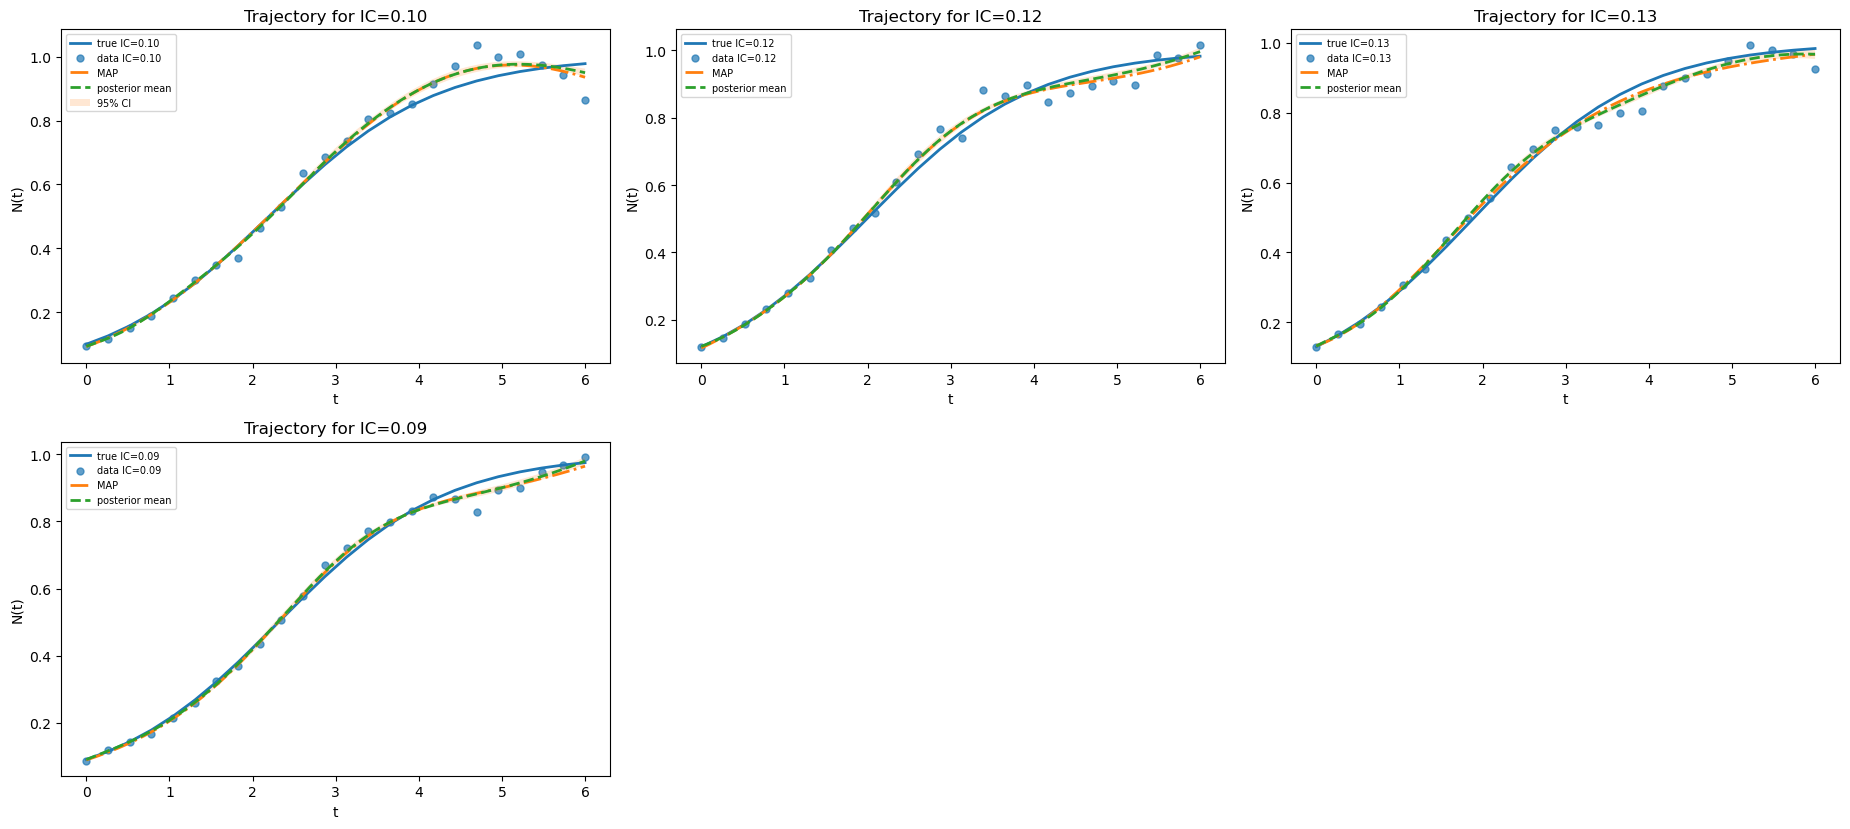

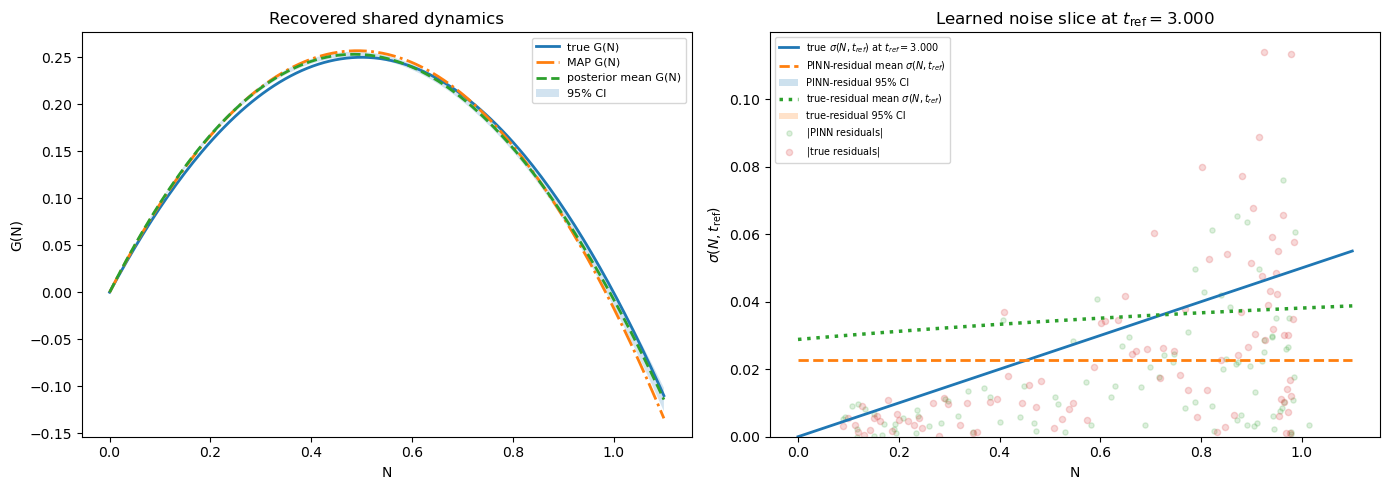

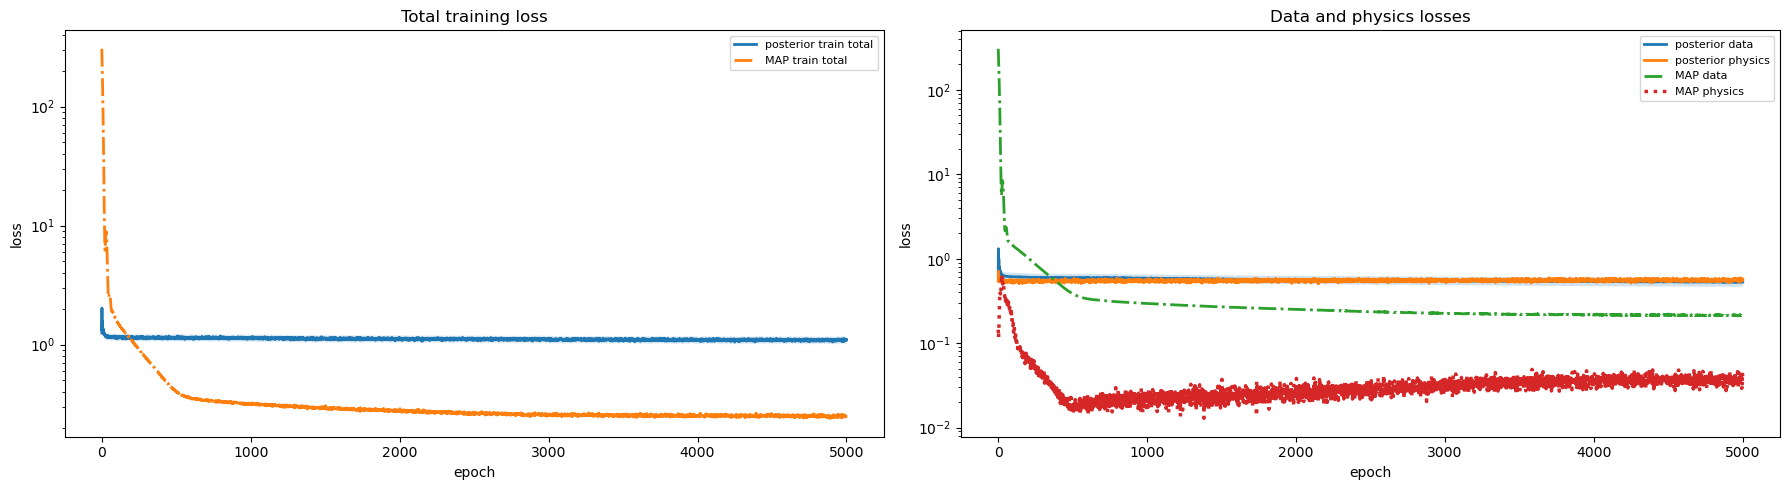

In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Pull posterior summaries from stored output
traj_mean_per_ic = rpinn_out["traj_mean_per_ic"]
traj_lo_per_ic = rpinn_out["traj_lo_per_ic"]
traj_hi_per_ic = rpinn_out["traj_hi_per_ic"]

rhs_mean = rpinn_out["rhs_mean"]
rhs_lo = rpinn_out["rhs_lo"]
rhs_hi = rpinn_out["rhs_hi"]

map_traj = rpinn_out["map_traj"]          # shape: [n_ics, n_t_plot]
map_rhs = rpinn_out["map_rhs"]            # shape: [n_N_grid]

# time arrays
t_obs_np = t_obs.squeeze(-1).cpu().numpy()
t_plot_np = t_plot.squeeze(1).cpu().numpy()
N_grid_np = N_grid.squeeze(1).cpu().numpy()

# reference time used for sigma(N, t_ref) slices
t_ref = 0.5 * (t_obs.min() + t_obs.max())
t_ref_val = float(t_ref.item())

# optional true sigma slice, if available
# expected shape: [len(N_grid), 1] or [len(N_grid)]
sigma_true_grid_np = None
if "sigma_true_grid" in locals():
    sigma_true_grid_np = sigma_true_grid.squeeze(-1).cpu().numpy()
elif "sigma_true_grid" in globals():
    sigma_true_grid_np = sigma_true_grid.squeeze(-1).cpu().numpy()

# flattened residual diagnostics for scatter
N_pinn_flat = N_pinn_seq.squeeze(-1).cpu().numpy().reshape(-1)
resid_pinn_abs_flat = np.abs(resid_pinn_seq.squeeze(-1).cpu().numpy().reshape(-1))

N_true_flat = N_true_seq.squeeze(-1).cpu().numpy().reshape(-1)
resid_true_abs_flat = np.abs(resid_true_seq.squeeze(-1).cpu().numpy().reshape(-1))


# ============================================================
# Figure 1: one subplot per IC
# ============================================================
ncols = 3
nrows = math.ceil(n_ics / ncols)

fig_ic, axes_ic = plt.subplots(
    nrows, ncols, figsize=(6.2 * ncols, 4.2 * nrows), squeeze=False
)
axes_ic = axes_ic.flatten()

for i in range(n_ics):
    ax = axes_ic[i]

    ax.plot(
        t_obs_np,
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={cfg.N0_list[i]:.2f}"
    )
    ax.scatter(
        t_obs_np,
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={cfg.N0_list[i]:.2f}"
    )

    # MAP trajectory
    ax.plot(
        t_plot_np,
        map_traj[i],
        "-.",
        linewidth=2,
        label="MAP"
    )

    # Posterior mean
    ax.plot(
        t_plot_np,
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label="posterior mean"
    )

    # Posterior CI
    ax.fill_between(
        t_plot_np,
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
        label="95% CI" if i == 0 else None
    )

    ax.set_xlabel("t")
    ax.set_ylabel("N(t)")
    ax.set_title(f"Trajectory for IC={cfg.N0_list[i]:.2f}")
    ax.legend(fontsize=7)

# Hide any unused axes
for j in range(n_ics, len(axes_ic)):
    axes_ic[j].axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: summary plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# 1) Recovered shared dynamics
# ------------------------------------------------------------
axes[0].plot(
    N_grid_np,
    G_grid_true.squeeze(1).cpu().numpy(),
    linewidth=2,
    label="true G(N)"
)
axes[0].plot(
    N_grid_np,
    map_rhs,
    "-.",
    linewidth=2,
    label="MAP G(N)"
)
axes[0].plot(
    N_grid_np,
    rhs_mean,
    "--",
    linewidth=2,
    label="posterior mean G(N)"
)
axes[0].fill_between(
    N_grid_np,
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI"
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("G(N)")
axes[0].set_title("Recovered shared dynamics")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# 2) Learned heteroscedastic noise slice sigma(N, t_ref)
# ------------------------------------------------------------
if sigma_true_grid_np is not None:
    axes[1].plot(
        N_grid_np,
        sigma_true_grid_np,
        linewidth=2,
        label=rf"true $\sigma(N, t_{{ref}})$ at $t_{{ref}}={t_ref_val:.3f}$"
    )

axes[1].plot(
    N_grid_np,
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=rf"PINN-residual mean $\sigma(N, t_{{ref}})$"
)
axes[1].fill_between(
    N_grid_np,
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI"
)

axes[1].plot(
    N_grid_np,
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=rf"true-residual mean $\sigma(N, t_{{ref}})$"
)
axes[1].fill_between(
    N_grid_np,
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI"
)

# residual clouds remain useful as diagnostics, though sigma also depends on t
axes[1].scatter(
    N_pinn_flat,
    resid_pinn_abs_flat,
    s=14,
    alpha=0.16,
    label=r"$|$PINN residuals$|$"
)
axes[1].scatter(
    N_true_flat,
    resid_true_abs_flat,
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$"
)

axes[1].set_xlabel("N")
axes[1].set_ylabel(r"$\sigma(N, t_{\mathrm{ref}})$")
axes[1].set_title(rf"Learned noise slice at $t_{{\mathrm{{ref}}}}={t_ref_val:.3f}$")
axes[1].legend(fontsize=7)
axes[1].set_ylim(bottom=0.0)

plt.tight_layout()
plt.show()


# ============================================================
# Figure 3: Multi-IC PINN losses, now with MAP overlays
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

epochs_init = np.arange(cfg.n_epochs_pinn)

train_pinn_total_mean, train_pinn_total_lo, train_pinn_total_hi = mean_and_ci(
    rpinn_out["train_pinn_total_histories"]
)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(
    rpinn_out["train_data_histories"]
)
train_phys_mean, train_phys_lo, train_phys_hi = mean_and_ci(
    rpinn_out["train_phys_histories"]
)

map_train_pinn_total = rpinn_out["map_train_pinn_total_history"]
map_train_data = rpinn_out["map_train_data_history"]
map_train_phys = rpinn_out["map_train_phys_history"]

# ------------------------------------------------------------
# 1) Total training loss
# ------------------------------------------------------------
axes[0].plot(epochs_init, train_pinn_total_mean, linewidth=2, label="posterior train total")
axes[0].fill_between(epochs_init, train_pinn_total_lo, train_pinn_total_hi, alpha=0.2)
axes[0].plot(epochs_init, map_train_pinn_total, "-.", linewidth=2, label="MAP train total")

axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Total training loss")
axes[0].legend(fontsize=8)

# ------------------------------------------------------------
# 2) Data loss + physics loss
# ------------------------------------------------------------
axes[1].plot(epochs_init, train_data_mean, linewidth=2, label="posterior data")
axes[1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)

axes[1].plot(epochs_init, train_phys_mean, linewidth=2, label="posterior physics")
axes[1].fill_between(epochs_init, train_phys_lo, train_phys_hi, alpha=0.2)

axes[1].plot(epochs_init, map_train_data, "-.", linewidth=2, label="MAP data")
axes[1].plot(epochs_init, map_train_phys, ":", linewidth=2.5, label="MAP physics")

axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("Data and physics losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
print("\nSummary")
print("-------")
print(f"Number of trajectories: {n_ics}")
print(f"IC values: {cfg.N0_list}")
# print(f"Mean PINN best validation loss: {rpinn_out['best_val_losses'].mean():.6e}")
print(f"Mean PINN best epoch: {rpinn_out['best_epochs'].mean():.2f}")
print(f"PINN residual rho mean: {rho_pinn_mean:.4f}")
print(f"True residual rho mean: {rho_truefit_mean:.4f}")
print(f"Empirical standardized residual rho: {rho_empirical:.4f}")


Summary
-------
Number of trajectories: 4
IC values: (0.1, 0.12, 0.13, 0.09)
Mean PINN best epoch: 4047.00
PINN residual rho mean: 0.2085
True residual rho mean: 0.5045
Empirical standardized residual rho: 0.3451


In [11]:
# ============================================================
# Noise + AR(1) residual diagnostics on one row
# ============================================================
with torch.no_grad():
    # from synthetic data dict
    y_true_all = data["y_true_all"]             # [n_ics, T, 1]
    y_data_all = data["y_data_all"]             # [n_ics, T, 1]
    N_grid = data["N_grid"]                     # [M, 1]
    sigma_true_grid = data["sigma_true_grid"]   # innovation sigma on grid, [M, 1]

    # fitted trajectories from PINN output
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)   # [n_ics, T]

    y_true_np = y_true_all.squeeze(-1).cpu().numpy()   # [n_ics, T]
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, T]

    # residuals against fitted mean trajectories
    residuals_all = y_data_np - obs_fit_mean_all       # [n_ics, T]
    N_fit_all = np.maximum(obs_fit_mean_all, 1e-8)     # [n_ics, T]

    # true residuals against true latent trajectories
    true_residuals_all = y_data_np - y_true_np         # [n_ics, T]
    N_true_all = np.maximum(y_true_np, 1e-8)           # [n_ics, T]

    # evaluate learned sigma(N) from PINN residual fit
    sigma_net_diag = sigma_pinn_results["best_models"][0]
    sigma_net_diag.eval()

    N_fit_all_torch = torch.tensor(
        N_fit_all[..., None], dtype=torch.float32, device=device
    )                                                   # [n_ics, T, 1]

    sigma_fit_all = sigma_net_diag(N_fit_all_torch).squeeze(-1).cpu().numpy()  # [n_ics, T]

    # AR(1): true innovation sigma and true residual std / expected abs residual
    sigma_true_innovation_grid = sigma_true_grid.squeeze(1).cpu().numpy()  # [M]
    sigma_true_residstd_grid = sigma_true_innovation_grid / np.sqrt(1.0 - cfg.rho_true ** 2)
    expected_abs_resid_grid = sigma_true_residstd_grid * np.sqrt(2.0 / np.pi)

    # evaluate theoretical curves at fitted states too, for optional diagnostics
    sigma_true_innovation_fit = cfg.noise_sig_coeff * np.maximum(N_fit_all, 1e-8) ** cfg.gamma
    sigma_true_residstd_fit = sigma_true_innovation_fit / np.sqrt(1.0 - cfg.rho_true ** 2)

    # true residual std evaluated at the true latent states
    sigma_true_innovation_true = cfg.noise_sig_coeff * np.maximum(N_true_all, 1e-8) ** cfg.gamma
    sigma_true_residstd_true = sigma_true_innovation_true / np.sqrt(1.0 - cfg.rho_true ** 2)

    # standardized residuals using learned sigma fit
    z_all = residuals_all / np.maximum(sigma_fit_all, 1e-8)   # [n_ics, T]

    z_prev = z_all[:, :-1].reshape(-1)
    z_next = z_all[:, 1:].reshape(-1)

    rho_empirical = np.sum(z_prev * z_next) / np.maximum(np.sum(z_prev ** 2), 1e-12)

    # standardized TRUE residuals using TRUE residual std
    z_true_all = true_residuals_all / np.maximum(sigma_true_residstd_true, 1e-8)  # [n_ics, T]

    z_true_prev = z_true_all[:, :-1].reshape(-1)
    z_true_next = z_true_all[:, 1:].reshape(-1)

    rho_empirical_true = np.sum(z_true_prev * z_true_next) / np.maximum(
        np.sum(z_true_prev ** 2), 1e-12
    )

    # flattened versions for plotting
    N_fit_flat = N_fit_all.reshape(-1)
    residuals_flat = residuals_all.reshape(-1)
    abs_residuals_flat = np.abs(residuals_flat)
    sigma_fit_flat = sigma_fit_all.reshape(-1)
    sigma_true_residstd_fit_flat = sigma_true_residstd_fit.reshape(-1)
    z_flat = z_all.reshape(-1)

# ============================================================
# Plot row: heteroscedastic noise + AR(1) diagnostics
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

N_grid_np = N_grid.squeeze(1).cpu().numpy()

# ------------------------------------------------------------
# 1. Learned heteroscedastic noise
# ------------------------------------------------------------

axes[0].plot(
    N_grid_np,
    expected_abs_resid_grid,
    linewidth=2,
    linestyle="-",
    color="black",
    label=r"theoretical $\mathbb{E}[|r|]=\sigma_{\rm res}\sqrt{2/\pi}$"
)
axes[0].plot(
    N_grid_np,
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean"
)
axes[0].fill_between(
    N_grid_np,
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI"
)
axes[0].plot(
    N_grid_np,
    sigma_truefit_mean,
    linewidth=2.5,
    linestyle="-.",
    label=r"true-residual $\sigma(N)$ mean"
)
axes[0].fill_between(
    N_grid_np,
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI"
)
axes[0].scatter(
    N_fit_flat,
    abs_residuals_flat,
    s=14,
    alpha=0.16,
    label=r"$|$residuals$|$"
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("scale")
axes[0].set_title("Learned heteroscedastic noise")
axes[0].legend(fontsize=7)

ymax0 = max(
    np.max(abs_residuals_flat) if abs_residuals_flat.size else 0.0,
    np.max(sigma_pinn_hi) if len(sigma_pinn_hi) else 0.0,
    np.max(sigma_truefit_hi) if len(sigma_truefit_hi) else 0.0,
    np.max(sigma_true_residstd_grid) if len(sigma_true_residstd_grid) else 0.0,
)
axes[0].set_ylim(0, 1.05 * ymax0)

# ------------------------------------------------------------
# 2. Lag-1 standardized residual scatter
# ------------------------------------------------------------
axes[1].scatter(z_prev, z_next, s=18, alpha=0.22, label="PINN-standardized")
axes[1].scatter(z_true_prev, z_true_next, s=18, alpha=0.18, label="true-standardized")

xmin = min(z_prev.min(), z_next.min(), z_true_prev.min(), z_true_next.min())
xmax = max(z_prev.max(), z_next.max(), z_true_prev.max(), z_true_next.max())

axes[1].plot(
    [xmin, xmax],
    [rho_empirical * xmin, rho_empirical * xmax],
    linewidth=2,
    label=fr"PINN empirical slope = {rho_empirical:.3f}"
)
axes[1].plot(
    [xmin, xmax],
    [rho_empirical_true * xmin, rho_empirical_true * xmax],
    linewidth=2,
    linestyle="--",
    label=fr"true empirical slope = {rho_empirical_true:.3f}"
)
axes[1].plot(
    [xmin, xmax],
    [cfg.rho_true * xmin, cfg.rho_true * xmax],
    color="black",
    linewidth=2.5,
    label=fr"true $\rho$ = {cfg.rho_true:.3f}"
)
axes[1].set_xlabel(r"$z_{k-1}$")
axes[1].set_ylabel(r"$z_k$")
axes[1].set_title("Lag-1 standardized residuals")
axes[1].legend(fontsize=8)

# ------------------------------------------------------------
# 3. Standardized residual sequence pairs
# ------------------------------------------------------------
axes[2].plot(z_prev, label=r"PINN $z_{k-1}$", alpha=0.8)
axes[2].plot(z_next, label=r"PINN $z_k$", alpha=0.8)
axes[2].plot(z_true_prev, label=r"true $z_{k-1}$", alpha=0.6, linestyle="--")
axes[2].plot(z_true_next, label=r"true $z_k$", alpha=0.6, linestyle="--")
axes[2].axhline(0.0, color="black", linewidth=1.5)
axes[2].set_xlabel("flattened lagged sample index")
axes[2].set_ylabel("standardized residual")
axes[2].set_title("Standardized residual sequence pairs")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"PINN empirical lag-1 slope:  {rho_empirical:.6f}")
print(f"True empirical lag-1 slope:  {rho_empirical_true:.6f}")
print(f"True rho:                    {cfg.rho_true:.6f}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x1 and 2x8)